# Análisis Exploratorio de Datos (EDA) y Separación de Conjuntos

Este notebook tiene como objetivo realizar una exploración inicial de los datos de vivienda en California y preparar los conjuntos de entrenamiento y prueba de manera estratificada.

## Objetivos:
1. Cargar el dataset.
2. Realizar un análisis estadístico y visual inicial.
3. Crear una categoría de ingresos para asegurar una separación representativa (estratificación).
4. Dividir los datos en `train_set` y `test_set`.

### 1. Configuración Inicial e Importaciones

In [1]:
# Importación de librerías y configuración de visualización
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuración de tamaños de fuente para los gráficos
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

### 2. Carga de los Datos
Importamos la ruta del archivo CSV desde la configuración centralizada del proyecto.

In [2]:
# Carga de los datos en un DataFrame de pandas
from housing.config import HOUSING_CSV

housing_full = pd.read_csv(HOUSING_CSV)

### 3. Exploración de Datos (EDA)
Visualizamos la estructura básica, tipos de datos y estadísticas descriptivas.

In [3]:
# Visualizamos las primeras filas para entender la estructura de los datos
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# Información detallada sobre las columnas y tipos de datos
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
# Conteo de valores nulos para identificar datos faltantes
housing_full["total_bedrooms"].isnull().sum()

np.int64(207)

In [6]:
# Distribución de la variable categórica ocean_proximity
housing_full["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
# Resumen estadístico de las variables numéricas
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### 4. Visualización de Distribuciones
Creamos histogramas para identificar sesgos, rangos y posibles valores atípicos.

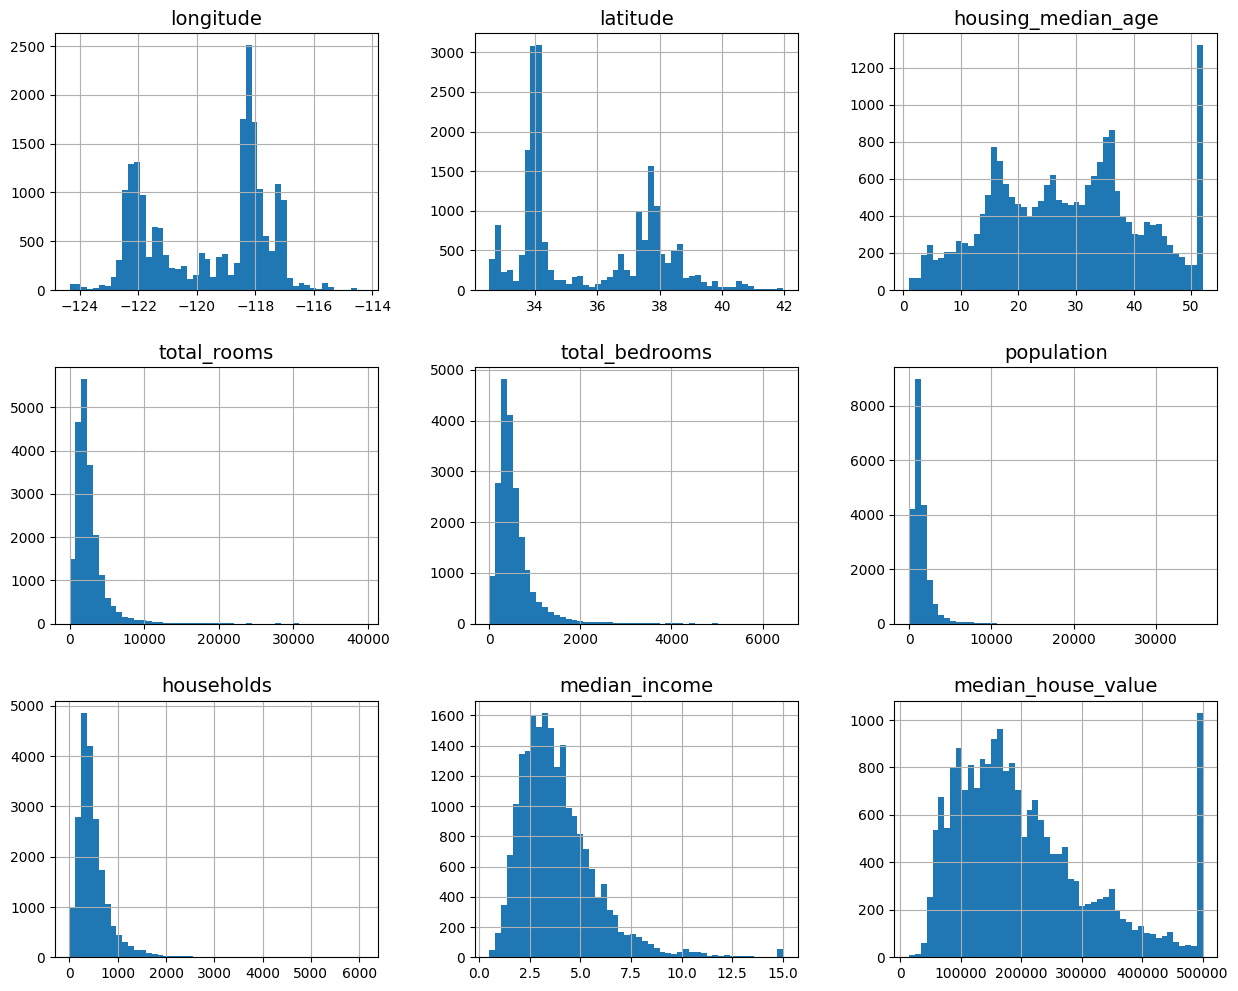

In [8]:
# Histograma general de todas las variables numéricas del dataset
housing_full.hist(bins=50, figsize=(15, 12))
plt.show()

### 5. Creación de Categorías para Estratificación
Creamos una variable categórica basada en los ingresos para asegurar un split representativo.

In [9]:
# Creación de la columna 'income_cat' dividiendo el ingreso medio en 5 categorías
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5])

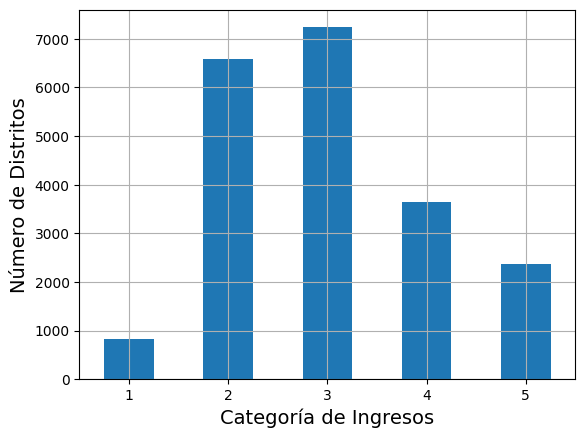

In [10]:
# Visualización de la distribución de las categorías de ingresos creadas
cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Categoría de Ingresos")
plt.ylabel("Número de Distritos")
plt.show()

### 6. Separación de Datos (Train/Test Split)
Utilizamos un split estratificado para garantizar que ambos conjuntos sean representativos.

In [11]:
# Dividimos el dataset en entrenamiento (80%) y prueba (20%) manteniendo proporciones de ingresos
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    housing_full, 
    test_size=0.2, 
    stratify=housing_full["income_cat"],
    random_state=42
)

print(f"Set de entrenamiento: {len(strat_train_set)}")
print(f"Set de prueba: {len(strat_test_set)}")

Set de entrenamiento: 16512
Set de prueba: 4128


### 7. Verificación de la Estratificación
Comparamos las proporciones en el dataset original frente al de prueba.

In [12]:
# Proporción de categorías en el conjunto completo original
housing_full["income_cat"].value_counts() / len(housing_full)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [13]:
# Proporción de categorías en el set de prueba (debe ser casi idéntica)
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

### 8. Limpieza de la columna de estratificacion
Eliminamos la columna auxiliar utilizada para la estratificación.

In [14]:
# Eliminamos la columna temporal 'income_cat' para dejar los sets finales limpios
strat_train_set = strat_train_set.drop(columns=["income_cat"], errors="ignore")
strat_test_set  = strat_test_set.drop(columns=["income_cat"], errors="ignore")

### 9. Exportación de Resultados
Guardamos los conjuntos de datos en archivos CSV dentro de la carpeta de splits.

In [15]:
# Exportación final de los datasets a archivos CSV
from housing.config import SPLIT_DIR

train_path = SPLIT_DIR / "housing_train_raw.csv"
test_path = SPLIT_DIR / "housing_test_raw.csv"

strat_train_set.to_csv(train_path, index=False)
strat_test_set.to_csv(test_path, index=False)